# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [1]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [2]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

Probability that a Binomial(10, 0.2) takes the value 2: 0.30198988800000004
Probability that a Binomial(10, 0.2) will take a value less than 2: 0.6777995263999999
Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? 4.0
Generate 2000 random values from a Binomial(10, 0.2) distribution: [1 4 3 ... 0 0 1]


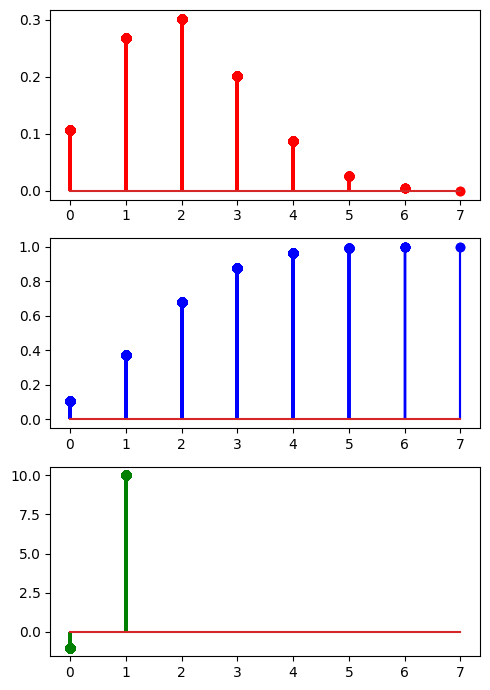

In [3]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

DISTRIBUCIÓN NORMAL (media=5, std=2)
Densidad de probabilidad en x=4 de una Normal(5, 2): 0.176033
Probabilidad de que una Normal(5, 2) tome un valor menor o igual a 4: 0.308538
Valor de una Normal(5, 2) con probabilidad acumulada 0.9: 7.563103
Primeros 10 valores aleatorios generados de una Normal(5, 2): [5.99342831 4.7234714  6.29537708 8.04605971 4.53169325 4.53172609
 8.15842563 6.53486946 4.06105123 6.08512009]


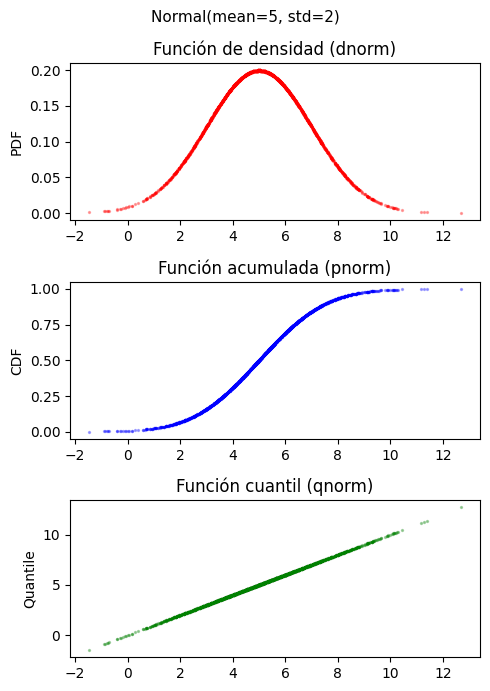


DISTRIBUCIÓN UNIFORME (min=0, max=1)
Densidad de probabilidad en x=0.5: 1.000000
Probabilidad de que X ≤ 0.5: 0.500000
Valor con probabilidad acumulada 0.9: 0.900000
Primeros 10 valores aleatorios generados: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258]


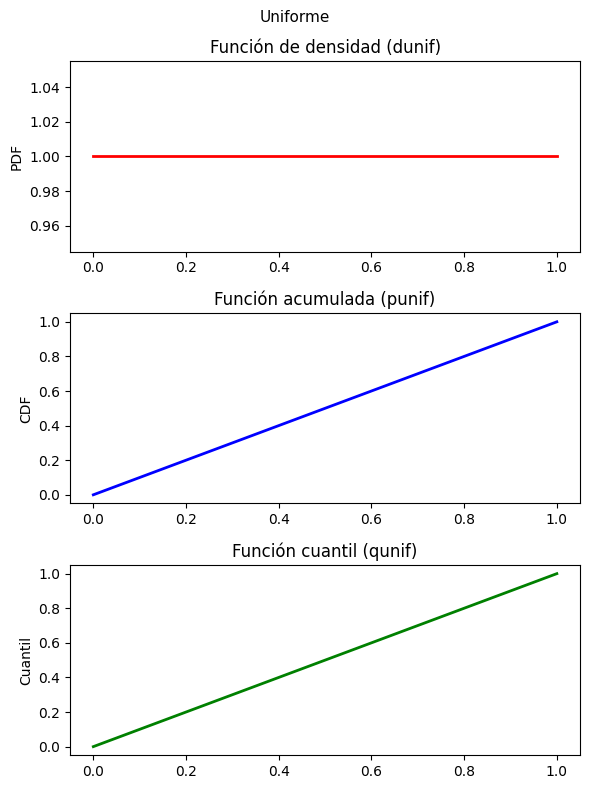

In [16]:
# DISTRIBUCIÓN NORMAL

from scipy.stats import norm, uniform
import numpy as np
import matplotlib.pyplot as plt

def dnorm(x, mean=0, std=1):
    """
    Calcula la densidad de probabilidad (PDF)
    """
    return norm.pdf(x, loc=mean, scale=std)

def pnorm(q, mean=0, std=1):
    """
    Calcula la probabilidad acumulada (CDF)
    """
    return norm.cdf(q, loc=mean, scale=std)

def qnorm(p, mean=0, std=1):
    """
    Calcula el cuantil a partir de la distribución normal
    """
    return norm.ppf(p, loc=mean, scale=std)

def rnorm(n, mean=0, std=1):
    """
    Genera n valores aleatorios
    """
    return norm.rvs(loc=mean, scale=std, size=n)

# Distribución Normal(mean=5, sd=2)
np.random.seed(42)
mean = 5
std = 2
print("DISTRIBUCIÓN NORMAL (media=5, std=2)")
print(f"Densidad de probabilidad en x=4 de una Normal(5, 2): {dnorm(4, mean=mean, std=std):.6f}")
print(f"Probabilidad de que una Normal(5, 2) tome un valor menor o igual a 4: {pnorm(4, mean=mean, std=std):.6f}")
print(f"Valor de una Normal(5, 2) con probabilidad acumulada 0.9: {qnorm(0.9, mean=mean, std=std):.6f}")
print(f"Primeros 10 valores aleatorios generados de una Normal(5, 2): {rnorm(2000, mean=mean, std=std)[:10]}")

# Gráficas distribución normal
np.random.seed(42)
data_norm = rnorm(2000, mean=mean, std=std)
pdf_norm = dnorm(data_norm, mean=mean, std=std)
cdf_norm = pnorm(data_norm, mean=mean, std=std)
ppf_norm = qnorm(np.clip(cdf_norm, 1e-6, 1 - 1e-6), mean=mean, std=std)

fig, axis = plt.subplots(3, 1, figsize=(5, 7))
fig.suptitle("Normal(mean=5, std=2)", fontsize=11)

axis[0].scatter(data_norm, pdf_norm, color="red", s=2, alpha=0.3)
axis[0].set_ylabel("PDF")
axis[0].set_title("Función de densidad (dnorm)")

axis[1].scatter(data_norm, cdf_norm, color="blue", s=2, alpha=0.3)
axis[1].set_ylabel("CDF")
axis[1].set_title("Función acumulada (pnorm)")

axis[2].scatter(data_norm, ppf_norm, color="green", s=2, alpha=0.3)
axis[2].set_ylabel("Quantile")
axis[2].set_title("Función cuantil (qnorm)")

plt.tight_layout()
plt.show()



# DISTRIBUCION UNIFORME

from scipy.stats import uniform
import numpy as np
import matplotlib.pyplot as plt

def dunif(x, min=0, max=1):
    """    Calcula la densidad de probabilidad (PDF)"""
    return uniform.pdf(x, loc=min, scale=max - min)

def punif(q, min=0, max=1):
    """Calcula la probabilidad acumulada (CDF)"""
    return uniform.cdf(q, loc=min, scale=max - min)

def qunif(p, min=0, max=1):
    """Calcula el cuantil (PPF)"""
    return uniform.ppf(p, loc=min, scale=max - min)

def runif(n, min=0, max=1):
    """Genera n valores aleatorios"""
    return uniform.rvs(loc=min, scale=max - min, size=n)

np.random.seed(42)
min_val = 0
max_val = 1

print("\nDISTRIBUCIÓN UNIFORME (min=0, max=1)")
print(f"Densidad de probabilidad en x=0.5: {dunif(0.5, min=min_val, max=max_val):.6f}")
print(f"Probabilidad de que X ≤ 0.5: {punif(0.5, min=min_val, max=max_val):.6f}")
print(f"Valor con probabilidad acumulada 0.9: {qunif(0.9, min=min_val, max=max_val):.6f}")
print(f"Primeros 10 valores aleatorios generados: {runif(2000, min=min_val, max=max_val)[:10]}")

low = 0
high = 1

# Valores para PDF y CDF
x = np.linspace(low, high, 100)

pdf = dunif(x, min=low, max=high)
cdf = punif(x, min=low, max=high)

# Valores de probabilidad para PPF (cuantil)
p = np.linspace(0, 1, 100)
ppf = qunif(p, min=low, max=high)

fig, axis = plt.subplots(3, 1, figsize=(6, 8))
fig.suptitle("Uniforme", fontsize=11)
axis[0].plot(x, pdf, "r-", lw=2)
axis[0].set_title("Función de densidad (dunif)")
axis[0].set_ylabel("PDF")

axis[1].plot(x, cdf, "b-", lw=2)
axis[1].set_title("Función acumulada (punif)")
axis[1].set_ylabel("CDF")

axis[2].plot(p, ppf, "g-", lw=2)
axis[2].set_title("Función cuantil (qunif)")
axis[2].set_ylabel("Cuantil")

plt.tight_layout()
plt.show()